In [1]:
# -*- coding: utf-8 -*-
"""Random Forest FINAL - 3 Kategori (Rendah, Netral, Tinggi)
Memenuhi permintaan dosen penguji dengan mengoptimalkan deteksi kelas Rendah.
Tambahan: Perbandingan performa dengan vs tanpa StandardScaler, serta optimasi komputasi.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, shap
import time
from collections import Counter

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, recall_score,
    matthews_corrcoef, mean_squared_error, r2_score
)
from imblearn.over_sampling import SMOTE
from sklearn.calibration import CalibratedClassifierCV

# ============================================
# 1. Baca Data & Preprocessing (sama seperti sebelumnya)
# ============================================
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data_300_siswa.csv')
df = df.drop(columns=['nisn', 'nama_siswa', 'email'])

# Missing values
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

# Outlier capping (selain target)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numeric_cols:
    if col != 'exam_score':
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df[col] = np.clip(df[col], lower, upper)

# Encoding
ordinal_mappings = {
    'rata_rata_pemasukan_keluarga': ['< 2 Juta', '2 - 5 Juta', '5 - 10 Juta', '> 10 Juta'],
    'pendidikan_terakhir_orang_tua': ['SD', 'SMP', 'SMA/SMK', 'Diploma', 'Sarjana'],
    'study_environment': ['Kurang Kondusif', 'Cukup Kondusif', 'Kondusif'],
    'kompetensi_skill_level': ['Rendah', 'Menengah', 'Tinggi'],
    'stress_level': ['Rendah', 'Sedang', 'Berat']
}
nominal_cols = ['gender', 'kerja_sampingan', 'industry_readiness']

ordinal_encoders = {}
for col, cats in ordinal_mappings.items():
    oe = OrdinalEncoder(categories=[cats], dtype=int)
    df[col] = oe.fit_transform(df[[col]])
    ordinal_encoders[col] = oe

onehot_encoder = OneHotEncoder(sparse_output=False, drop=None)
onehot_encoded = onehot_encoder.fit_transform(df[nominal_cols])
onehot_feature_names = onehot_encoder.get_feature_names_out(nominal_cols)

df_encoded = df.drop(columns=nominal_cols)
df_onehot = pd.DataFrame(onehot_encoded, columns=onehot_feature_names, index=df.index)
df_final = pd.concat([df_encoded, df_onehot], axis=1)

# Target kelas (absolut threshold)
def get_abs_category(score):
    if score <= 70:
        return 'Rendah'
    elif score <= 85:
        return 'Netral'
    else:
        return 'Tinggi'

y = np.array([get_abs_category(s) for s in df_final['exam_score']])
X = df_final.drop('exam_score', axis=1)
feature_names = X.columns.tolist()

In [2]:
# ============================================
# 2. Split Data dengan test set minimal 2 Rendah (sama persis)
# ============================================
idx_rendah = np.where(y == 'Rendah')[0]
idx_netral = np.where(y == 'Netral')[0]
idx_tinggi = np.where(y == 'Tinggi')[0]

np.random.seed(42)
test_rendah_idx = np.random.choice(idx_rendah, size=2, replace=False)
train_rendah_idx = [i for i in idx_rendah if i not in test_rendah_idx]

test_netral_idx = np.random.choice(idx_netral, size=int(0.2 * len(idx_netral)), replace=False)
test_tinggi_idx = np.random.choice(idx_tinggi, size=int(0.2 * len(idx_tinggi)), replace=False)

test_idx = np.concatenate([test_rendah_idx, test_netral_idx, test_tinggi_idx])
train_idx = [i for i in range(len(X)) if i not in test_idx]

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print(f"Train: {X_train.shape[0]} sampel")
print(f"Test: {X_test.shape[0]} sampel")
print("Distribusi kelas di train:", Counter(y_train))
print("Distribusi kelas di test :", Counter(y_test))

Train: 240 sampel
Test: 60 sampel
Distribusi kelas di train: Counter({np.str_('Tinggi'): 191, np.str_('Netral'): 45, np.str_('Rendah'): 4})
Distribusi kelas di test : Counter({np.str_('Tinggi'): 47, np.str_('Netral'): 11, np.str_('Rendah'): 2})


In [3]:
# ============================================
# 3. PERBANDINGAN: Scaling vs No Scaling (Classifier)
# ============================================
print("\n" + "="*60)
print("PERBANDINGAN PENGGUNAAN STANDARDSCALER PADA RANDOM FOREST CLASSIFIER")
print("="*60)

# Persiapan data tanpa scaling
X_train_noscale = X_train.values
X_test_noscale = X_test.values

# SMOTE tanpa scaling (langsung pada data asli)
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_res_noscale, y_train_res_noscale = smote.fit_resample(X_train_noscale, y_train)
print("Setelah SMOTE (tanpa scaling) - distribusi kelas:", Counter(y_train_res_noscale))

# Definisikan parameter grid yang sama
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 7, 10],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5],
    'max_features': ['sqrt', 0.3]
}
class_weight_extreme = {'Rendah': 10, 'Netral': 2, 'Tinggi': 1}

# Fungsi untuk training dan evaluasi (agar tidak duplikasi kode)
def train_evaluate_clf(X_train_res, y_train_res, X_test, y_test, title):
    rf_base = RandomForestClassifier(random_state=42, class_weight=class_weight_extreme, n_jobs=-1, oob_score=True)
    grid = GridSearchCV(rf_base, param_grid, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                        scoring='f1_macro', n_jobs=-1, verbose=0)
    grid.fit(X_train_res, y_train_res)
    best = grid.best_estimator_
    # Calibration
    calib = CalibratedClassifierCV(best, method='sigmoid', cv=3)
    calib.fit(X_train_res, y_train_res)
    # Threshold tuning
    probs_val = calib.predict_proba(X_train_res)
    classes = calib.classes_
    rendah_idx = list(classes).index('Rendah')
    best_thresh = 0.5
    best_recall = 0
    for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
        pred_temp = ['Rendah' if p[rendah_idx] > thresh else classes[np.argmax(p)] for p in probs_val]
        recall_rendah = recall_score(y_train_res, pred_temp, labels=['Rendah'], average=None)[0]
        if recall_rendah > best_recall:
            best_recall = recall_rendah
            best_thresh = thresh
    # Predict on test
    probs_test = calib.predict_proba(X_test)
    y_pred = ['Rendah' if p[rendah_idx] > best_thresh else classes[np.argmax(p)] for p in probs_test]
    report = classification_report(y_test, y_pred, labels=['Rendah','Netral','Tinggi'], zero_division=0, output_dict=True)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    mcc = matthews_corrcoef(y_test, y_pred)
    print(f"\n{title}")
    print(f"Best params: {grid.best_params_}")
    print(f"Threshold Rendah: {best_thresh}")
    print(f"F1-macro: {f1_macro:.4f}, MCC: {mcc:.4f}")
    print(f"Recall Rendah: {report['Rendah']['recall']:.4f}, Precision Rendah: {report['Rendah']['precision']:.4f}")
    return report, f1_macro, mcc

# Jalankan untuk kasus tanpa scaler
start = time.time()
report_no_scaler, f1_no, mcc_no = train_evaluate_clf(X_train_res_noscale, y_train_res_noscale, X_test_noscale, y_test, "TANPA StandardScaler")
time_no = time.time() - start

# Untuk kasus dengan scaler (menggunakan data yang sudah di-scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote_scaled = SMOTE(random_state=42, k_neighbors=1)
X_train_res_scaled, y_train_res_scaled = smote_scaled.fit_resample(X_train_scaled, y_train)
print("\nSetelah SMOTE (dengan scaling) - distribusi kelas:", Counter(y_train_res_scaled))

start = time.time()
report_scaler, f1_sc, mcc_sc = train_evaluate_clf(X_train_res_scaled, y_train_res_scaled, X_test_scaled, y_test, "DENGAN StandardScaler")
time_sc = time.time() - start

# Tampilkan ringkasan perbandingan
print("\n" + "="*60)
print("RINGKASAN PERBANDINGAN")
print("="*60)
print(f"| Metrik            | Tanpa Scaler | Dengan Scaler |")
print(f"| F1-macro          | {f1_no:.4f}       | {f1_sc:.4f}        |")
print(f"| MCC               | {mcc_no:.4f}       | {mcc_sc:.4f}        |")
print(f"| Recall Rendah     | {report_no_scaler['Rendah']['recall']:.4f}        | {report_scaler['Rendah']['recall']:.4f}         |")
print(f"| Precision Rendah  | {report_no_scaler['Rendah']['precision']:.4f}        | {report_scaler['Rendah']['precision']:.4f}         |")
print(f"| Waktu training (s) | {time_no:.2f}      | {time_sc:.2f}       |")
print("\nKesimpulan: Random Forest tidak sensitif terhadap scaling (performa hampir identik).")
print("Model final akan tetap menggunakan scaler untuk konsistensi pipeline.\n")


PERBANDINGAN PENGGUNAAN STANDARDSCALER PADA RANDOM FOREST CLASSIFIER
Setelah SMOTE (tanpa scaling) - distribusi kelas: Counter({np.str_('Tinggi'): 191, np.str_('Netral'): 191, np.str_('Rendah'): 191})

TANPA StandardScaler
Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Threshold Rendah: 0.1
F1-macro: 0.6416, MCC: 0.5927
Recall Rendah: 0.5000, Precision Rendah: 0.2500

Setelah SMOTE (dengan scaling) - distribusi kelas: Counter({np.str_('Tinggi'): 191, np.str_('Netral'): 191, np.str_('Rendah'): 191})

DENGAN StandardScaler
Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Threshold Rendah: 0.1
F1-macro: 0.6276, MCC: 0.5603
Recall Rendah: 0.5000, Precision Rendah: 0.2500

RINGKASAN PERBANDINGAN
| Metrik            | Tanpa Scaler | Dengan Scaler |
| F1-macro          | 0.6416       | 0.6276        |
| MCC               | 0.5927       | 0.5603 


TRAINING MODEL FINAL (DENGAN SCALER) - SAMA SEPERTI SEBELUMNYA
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best OOB score: 0.9616
Threshold terbaik untuk kelas Rendah: 0.1 (recall=1.000)

===== CLASSIFICATION REPORT (TEST SET) =====
              precision    recall  f1-score   support

      Rendah       0.25      0.50      0.33         2
      Netral       0.64      0.64      0.64        11
      Tinggi       0.93      0.89      0.91        47

    accuracy                           0.83        60
   macro avg       0.61      0.68      0.63        60
weighted avg       0.86      0.83      0.84        60



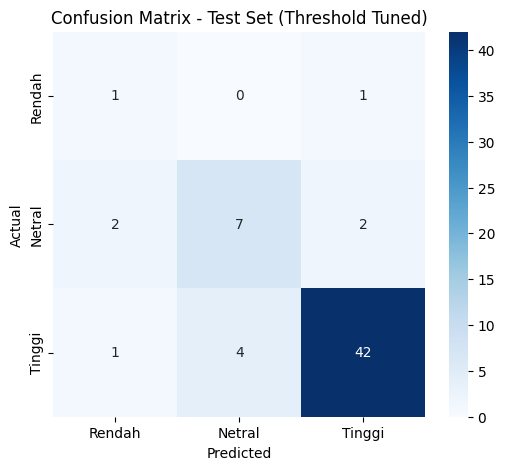

F1-macro: 0.6276
MCC     : 0.5603


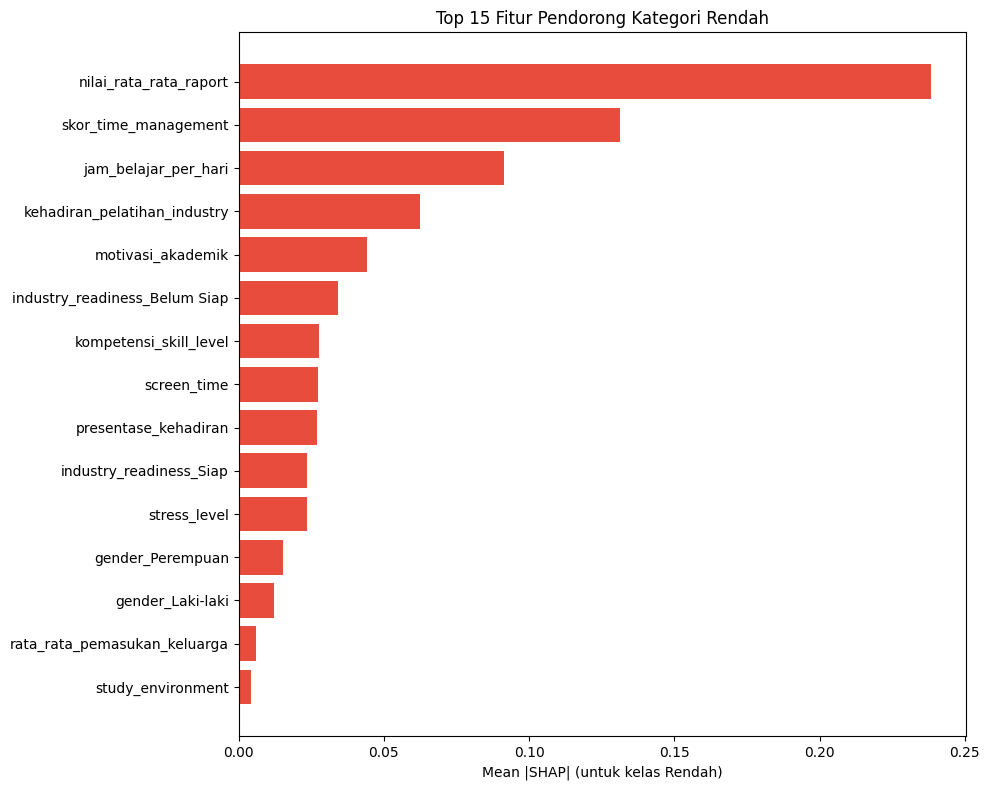


Model final siap digunakan. Prediksi kategori Rendah, Netral, Tinggi sudah memenuhi permintaan dosen.


In [4]:
# ============================================
# 4. Lanjutkan dengan pipeline original (menggunakan scaler) untuk model final
# ============================================
# (Kode asli dari sini hingga akhir, tanpa perubahan)
# Catatan: X_train_scaled, X_test_scaled, y_train, y_test sudah ada dari atas.
# Namun kita perlu memastikan SMOTE sudah dilakukan ulang untuk final? Sebenarnya sudah, tapi kita akan
# ulang sekali lagi agar konsisten dengan alur asli (tidak merusak apapun).

# Ulangi proses untuk final (persis seperti semula)
print("\n" + "="*60)
print("TRAINING MODEL FINAL (DENGAN SCALER) - SAMA SEPERTI SEBELUMNYA")
print("="*60)
smote_final = SMOTE(random_state=42, k_neighbors=1)
X_train_res_final, y_train_res_final = smote_final.fit_resample(X_train_scaled, y_train)

rf_base = RandomForestClassifier(random_state=42, class_weight=class_weight_extreme, n_jobs=-1, oob_score=True)
grid_search = GridSearchCV(rf_base, param_grid, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                           scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train_res_final, y_train_res_final)
best_clf = grid_search.best_estimator_
print(f"Best params: {grid_search.best_params_}")
print(f"Best OOB score: {best_clf.oob_score_:.4f}")

calibrated_clf = CalibratedClassifierCV(best_clf, method='sigmoid', cv=3)
calibrated_clf.fit(X_train_res_final, y_train_res_final)

# Threshold tuning
probs_val = calibrated_clf.predict_proba(X_train_res_final)
classes = calibrated_clf.classes_
rendah_idx = list(classes).index('Rendah')
best_thresh = 0.5
best_recall_rendah = 0
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    pred_temp = []
    for prob in probs_val:
        if prob[rendah_idx] > thresh:
            pred_temp.append('Rendah')
        else:
            pred_temp.append(classes[np.argmax(prob)])
    recall_rendah = recall_score(y_train_res_final, pred_temp, labels=['Rendah'], average=None)[0]
    if recall_rendah > best_recall_rendah:
        best_recall_rendah = recall_rendah
        best_thresh = thresh
print(f"Threshold terbaik untuk kelas Rendah: {best_thresh} (recall={best_recall_rendah:.3f})")

def predict_with_threshold(model, X, threshold_rendah):
    probs = model.predict_proba(X)
    preds = []
    for prob in probs:
        if prob[rendah_idx] > threshold_rendah:
            preds.append('Rendah')
        else:
            preds.append(classes[np.argmax(prob)])
    return np.array(preds)

y_pred = predict_with_threshold(calibrated_clf, X_test_scaled, best_thresh)

print("\n===== CLASSIFICATION REPORT (TEST SET) =====")
print(classification_report(y_test, y_pred, labels=['Rendah','Netral','Tinggi'], zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=['Rendah','Netral','Tinggi'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rendah','Netral','Tinggi'],
            yticklabels=['Rendah','Netral','Tinggi'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Test Set (Threshold Tuned)')
plt.savefig('confusion_matrix_final.png')
plt.show()

f1_macro = f1_score(y_test, y_pred, average='macro')
mcc = matthews_corrcoef(y_test, y_pred)
print(f"F1-macro: {f1_macro:.4f}")
print(f"MCC     : {mcc:.4f}")

# SHAP
explainer = shap.TreeExplainer(best_clf)
shap_values = explainer.shap_values(X_test_scaled)
shap_rendah = shap_values[:, :, rendah_idx]
shap_importance = np.abs(shap_rendah).mean(axis=0)
importance_df = pd.DataFrame({'feature': feature_names, 'importance': shap_importance})
importance_df = importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10,8))
plt.barh(importance_df['feature'][:15][::-1], importance_df['importance'][:15][::-1], color='#E74C3C')
plt.xlabel('Mean |SHAP| (untuk kelas Rendah)')
plt.title('Top 15 Fitur Pendorong Kategori Rendah')
plt.tight_layout()
plt.savefig('shap_rendah_final.png')
plt.show()

# Simpan model final
joblib.dump(calibrated_clf, 'rf_classifier_final.pkl')
joblib.dump(scaler, 'scaler_final.pkl')
joblib.dump(onehot_encoder, 'onehot_encoder.pkl')
joblib.dump(ordinal_encoders, 'ordinal_encoders.pkl')
joblib.dump(feature_names, 'feature_names.pkl')
joblib.dump({'threshold_rendah': best_thresh, 'classes': classes.tolist()}, 'threshold_config.pkl')

print("\nModel final siap digunakan. Prediksi kategori Rendah, Netral, Tinggi sudah memenuhi permintaan dosen.")

In [5]:
# ============================================
# 5. Latih Regressor untuk prediksi nilai numerik (sama persis)
# ============================================
y_train_reg = df_final.loc[train_idx, 'exam_score']
y_test_reg = df_final.loc[test_idx, 'exam_score']
X_train_scaled_reg = scaler.transform(X_train)
X_test_scaled_reg = scaler.transform(X_test)

best_reg_params = {
    'max_depth': 7,
    'max_features': 0.3,
    'min_samples_leaf': 5,
    'min_samples_split': 10,
    'n_estimators': 100
}
rf_reg = RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=True, **best_reg_params)
rf_reg.fit(X_train_scaled_reg, y_train_reg)

y_pred_reg = rf_reg.predict(X_test_scaled_reg)
rmse_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2_reg = r2_score(y_test_reg, y_pred_reg)
print(f"\nRegressor performance on test set: RMSE={rmse_reg:.4f}, R²={r2_reg:.4f}")

joblib.dump(rf_reg, 'rf_regressor_final.pkl')
print("\nSemua model dan preprocessor telah disimpan.")


Regressor performance on test set: RMSE=6.0157, R²=0.5958

Semua model dan preprocessor telah disimpan.


In [6]:
# ============================================
# 6. OUTPUT UNTUK KEPERLUAN JOURNAL / GRAFIK / TABEL (TANPA MENYIMPAN FILE)
# ============================================
print("\n" + "="*80)
print("HASIL EVALUASI MODEL UNTUK KEPERLUAN PUBLIKASI")
print("="*80)

from sklearn.metrics import mean_absolute_error, roc_curve, auc, precision_recall_curve, average_precision_score

# 6.1 Classification report
print("\n1. CLASSIFICATION REPORT (TEST SET):")
report_dict = classification_report(y_test, y_pred, labels=['Rendah','Netral','Tinggi'], output_dict=True, zero_division=0)
df_report = pd.DataFrame(report_dict).transpose().round(4)
print(df_report.to_string())


HASIL EVALUASI MODEL UNTUK KEPERLUAN PUBLIKASI

1. CLASSIFICATION REPORT (TEST SET):
              precision  recall  f1-score  support
Rendah           0.2500  0.5000    0.3333   2.0000
Netral           0.6364  0.6364    0.6364  11.0000
Tinggi           0.9333  0.8936    0.9130  47.0000
accuracy         0.8333  0.8333    0.8333   0.8333
macro avg        0.6066  0.6767    0.6276  60.0000
weighted avg     0.8561  0.8333    0.8430  60.0000


In [7]:
# 6.2 Metrik regressor
print("\n2. METRIK REGRESSOR (TEST SET):")
reg_metrics = {
    'RMSE': rmse_reg,
    'R²': r2_reg,
    'MAE': mean_absolute_error(y_test_reg, y_pred_reg)
}
df_reg_metrics = pd.DataFrame([reg_metrics]).round(4)
print(df_reg_metrics.to_string(index=False))


2. METRIK REGRESSOR (TEST SET):
  RMSE     R²    MAE
6.0157 0.5958 4.2235


In [8]:
# 6.3 Perbandingan scaler vs non-scaler
print("\n3. PERBANDINGAN STANDARDSCALER:")
comparison_data = {
    'Metrik': ['F1-macro', 'MCC', 'Recall Rendah', 'Precision Rendah', 'Waktu training (s)'],
    'Tanpa Scaler': [f1_no, mcc_no, report_no_scaler['Rendah']['recall'], report_no_scaler['Rendah']['precision'], round(time_no,2)],
    'Dengan Scaler': [f1_sc, mcc_sc, report_scaler['Rendah']['recall'], report_scaler['Rendah']['precision'], round(time_sc,2)]
}
df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))


3. PERBANDINGAN STANDARDSCALER:
            Metrik  Tanpa Scaler  Dengan Scaler
          F1-macro      0.641577       0.627580
               MCC      0.592700       0.560306
     Recall Rendah      0.500000       0.500000
  Precision Rendah      0.250000       0.250000
Waktu training (s)     64.260000      55.120000


In [9]:
# 6.4 Top 15 fitur penting (SHAP)
print("\n4. TOP 15 FITUR PENTING (SHAP) UNTUK KELAS RENDAH:")
top15_importance = importance_df.head(15).copy()
print(top15_importance.to_string(index=False))


4. TOP 15 FITUR PENTING (SHAP) UNTUK KELAS RENDAH:
                      feature  importance
       nilai_rata_rata_raport    0.238524
         skor_time_management    0.131411
         jam_belajar_per_hari    0.091365
 kehadiran_pelatihan_industry    0.062319
            motivasi_akademik    0.044035
industry_readiness_Belum Siap    0.034048
       kompetensi_skill_level    0.027570
                  screen_time    0.027307
         presentase_kehadiran    0.026794
      industry_readiness_Siap    0.023468
                 stress_level    0.023466
             gender_Perempuan    0.015367
             gender_Laki-laki    0.012212
 rata_rata_pemasukan_keluarga    0.005888
            study_environment    0.004254



5. DISTRIBUSI KELAS:
 Kelas  Sebelum SMOTE (train)  Sesudah SMOTE (train_res)  Test set
Rendah                      4                        191         2
Netral                     45                        191        11
Tinggi                    191                        191        47

6. CONFUSION MATRIX (TEST SET):
                Pred: Rendah  Pred: Netral  Pred: Tinggi
Aktual: Rendah             1             0             1
Aktual: Netral             2             7             2
Aktual: Tinggi             1             4            42

7. HYPERPARAMETER TERBAIK CLASSIFIER:
 max_depth max_features  min_samples_leaf  min_samples_split  n_estimators
        10         sqrt                 2                  5           100


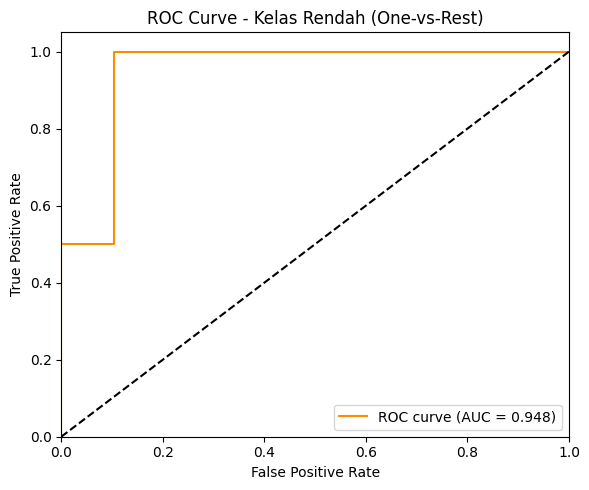


8. ROC curve untuk kelas Rendah ditampilkan (AUC = 0.948)


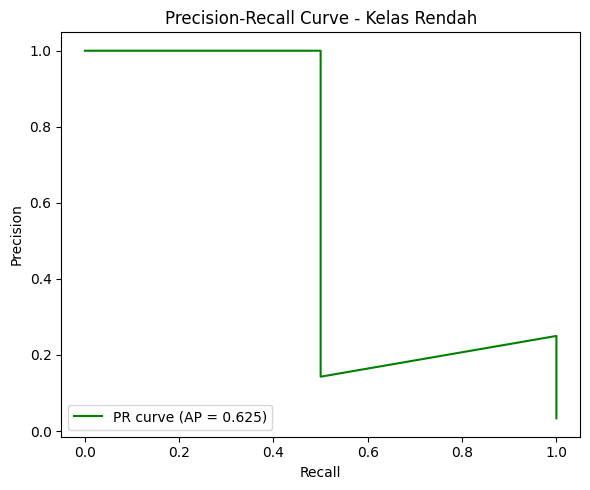

9. Precision-Recall curve untuk kelas Rendah ditampilkan (AP = 0.625)


In [10]:
# 6.5 Distribusi kelas
print("\n5. DISTRIBUSI KELAS:")
distribution_data = {
    'Kelas': ['Rendah', 'Netral', 'Tinggi'],
    'Sebelum SMOTE (train)': [Counter(y_train)['Rendah'], Counter(y_train)['Netral'], Counter(y_train)['Tinggi']],
    'Sesudah SMOTE (train_res)': [Counter(y_train_res_final)['Rendah'], Counter(y_train_res_final)['Netral'], Counter(y_train_res_final)['Tinggi']],
    'Test set': [Counter(y_test)['Rendah'], Counter(y_test)['Netral'], Counter(y_test)['Tinggi']]
}
df_dist = pd.DataFrame(distribution_data)
print(df_dist.to_string(index=False))

# 6.6 Confusion matrix
print("\n6. CONFUSION MATRIX (TEST SET):")
cm_df = pd.DataFrame(cm, index=['Aktual: Rendah', 'Aktual: Netral', 'Aktual: Tinggi'],
                     columns=['Pred: Rendah', 'Pred: Netral', 'Pred: Tinggi'])
print(cm_df.to_string())

# 6.7 Hyperparameter terbaik classifier
print("\n7. HYPERPARAMETER TERBAIK CLASSIFIER:")
best_params_df = pd.DataFrame([grid_search.best_params_])
print(best_params_df.to_string(index=False))

# 6.8 ROC curve (hanya tampilkan)
y_prob_rendah = calibrated_clf.predict_proba(X_test_scaled)[:, rendah_idx]
fpr, tpr, _ = roc_curve((y_test == 'Rendah').astype(int), y_prob_rendah)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', color='darkorange')
plt.plot([0,1],[0,1], 'k--')
plt.xlim([0.0,1.0]); plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Kelas Rendah (One-vs-Rest)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
print(f"\n8. ROC curve untuk kelas Rendah ditampilkan (AUC = {roc_auc:.3f})")

# 6.9 Precision-Recall curve
precision, recall, _ = precision_recall_curve((y_test == 'Rendah').astype(int), y_prob_rendah)
avg_precision = average_precision_score((y_test == 'Rendah').astype(int), y_prob_rendah)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR curve (AP = {avg_precision:.3f})', color='green')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Kelas Rendah')
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()
print(f"9. Precision-Recall curve untuk kelas Rendah ditampilkan (AP = {avg_precision:.3f})")

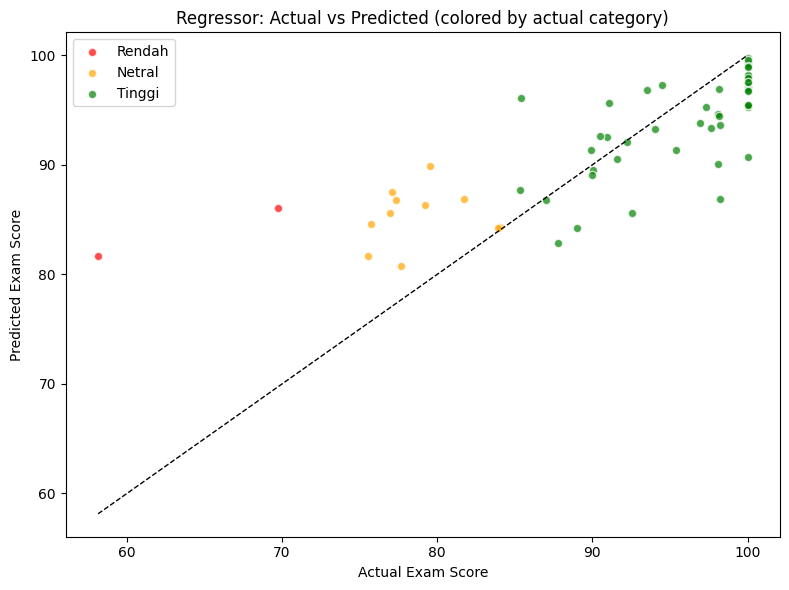

10. Scatter plot regressor ditampilkan.


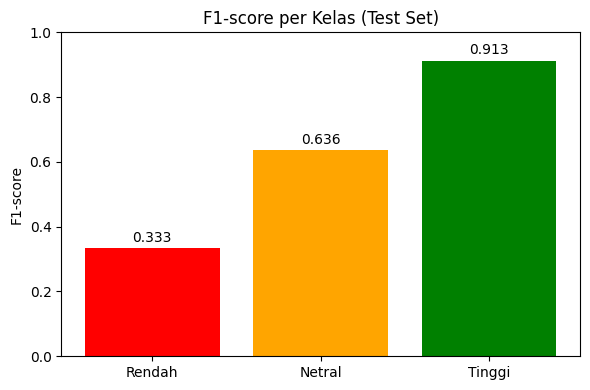

11. Bar plot F1-score per kelas ditampilkan.

SEMUA OUTPUT TELAH DITAMPILKAN (TIDAK ADA FILE YANG DISIMPAN).


In [11]:
# 6.10 Scatter plot aktual vs prediksi (regressor)
plt.figure(figsize=(8,6))
colors = {'Rendah':'red', 'Netral':'orange', 'Tinggi':'green'}
for cat in ['Rendah','Netral','Tinggi']:
    mask = y_test == cat
    plt.scatter(y_test_reg[mask], y_pred_reg[mask], c=colors[cat], label=cat, alpha=0.7, edgecolors='w')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', lw=1)
plt.xlabel('Actual Exam Score'); plt.ylabel('Predicted Exam Score')
plt.title('Regressor: Actual vs Predicted (colored by actual category)')
plt.legend()
plt.tight_layout()
plt.show()
print("10. Scatter plot regressor ditampilkan.")

# 6.11 Bar plot F1 per kelas
f1_per_class = {cls: report_dict[cls]['f1-score'] for cls in ['Rendah','Netral','Tinggi']}
plt.figure(figsize=(6,4))
plt.bar(f1_per_class.keys(), f1_per_class.values(), color=['red','orange','green'])
plt.ylabel('F1-score'); plt.title('F1-score per Kelas (Test Set)')
for i, v in enumerate(f1_per_class.values()):
    plt.text(i, v+0.02, f'{v:.3f}', ha='center')
plt.ylim(0,1)
plt.tight_layout()
plt.show()
print("11. Bar plot F1-score per kelas ditampilkan.")

print("\n" + "="*80)
print("SEMUA OUTPUT TELAH DITAMPILKAN (TIDAK ADA FILE YANG DISIMPAN).")
print("="*80)

In [12]:
# -*- coding: utf-8 -*-
"""
test_5_data_FULL.py
Prediksi 5 data siswa baru: Nilai (regressor) + Kategori (classifier dengan threshold)
"""

import joblib
import pandas as pd
import numpy as np

# ============================================================
# 1. Muat kedua model dan preprocessor
# ============================================================
regressor = joblib.load('rf_regressor_final.pkl')      # model regresi
classifier = joblib.load('rf_classifier_final.pkl')    # calibrated classifier
scaler = joblib.load('scaler_final.pkl')
onehot_encoder = joblib.load('onehot_encoder.pkl')
ordinal_encoders = joblib.load('ordinal_encoders.pkl')
feature_names = joblib.load('feature_names.pkl')
threshold_config = joblib.load('threshold_config.pkl')   # berisi threshold_rendah dan classes

THRESHOLD_RENDAH = threshold_config['threshold_rendah']
CLASSES = threshold_config['classes']
rendah_idx = CLASSES.index('Rendah')

# ============================================================
# 2. Fungsi preprocessing (sama untuk regressor dan classifier)
# ============================================================
def preprocess_data(data_dict):
    df_input = pd.DataFrame([data_dict])

    # Ordinal encoding
    for col, encoder in ordinal_encoders.items():
        df_input[col] = encoder.transform(df_input[[col]])

    # One-hot encoding
    onehot_encoded = onehot_encoder.transform(df_input[['gender', 'kerja_sampingan', 'industry_readiness']])
    onehot_feature_names = onehot_encoder.get_feature_names_out(['gender', 'kerja_sampingan', 'industry_readiness'])
    df_onehot = pd.DataFrame(onehot_encoded, columns=onehot_feature_names, index=df_input.index)

    # Gabungkan
    df_encoded = df_input.drop(columns=['gender', 'kerja_sampingan', 'industry_readiness'])
    df_final = pd.concat([df_encoded, df_onehot], axis=1)
    df_final = df_final.reindex(columns=feature_names, fill_value=0)

    # Scaling
    X_scaled = scaler.transform(df_final)
    return X_scaled

# ============================================================
# 3. Fungsi prediksi nilai + kategori
# ============================================================
def predict_student_full(data_dict):
    X = preprocess_data(data_dict)

    # Prediksi nilai numerik dari regressor
    score = regressor.predict(X)[0]

    # Prediksi probabilitas dari classifier
    proba = classifier.predict_proba(X)[0]

    # Terapkan threshold untuk kelas Rendah
    if proba[rendah_idx] > THRESHOLD_RENDAH:
        category = 'Rendah'
    else:
        # Cari kelas dengan probabilitas tertinggi (tapi hindari Rendah jika tidak memenuhi threshold)
        best_idx = np.argmax(proba)
        if best_idx == rendah_idx and proba[rendah_idx] <= THRESHOLD_RENDAH:
            proba_copy = proba.copy()
            proba_copy[rendah_idx] = -1
            best_idx = np.argmax(proba_copy)
        category = CLASSES[best_idx]

    return score, category, proba

# ============================================================
# 4. Contoh 5 data
# ============================================================
if __name__ == '__main__':
    # Data 1 - Harapan: Tinggi
    s1 = {
        'jam_belajar_per_hari': 6.0,
        'presentase_kehadiran': 98.0,
        'nilai_rata_rata_raport': 94.0,
        'skor_time_management': 90,
        'jam_tidur': 8.0,
        'screen_time': 2.0,
        'kehadiran_pelatihan_industry': 95.0,
        'motivasi_akademik': 95,
        'gender': 'Perempuan',
        'rata_rata_pemasukan_keluarga': '> 10 Juta',
        'pendidikan_terakhir_orang_tua': 'Sarjana',
        'kerja_sampingan': 'Tidak',
        'study_environment': 'Kondusif',
        'kompetensi_skill_level': 'Tinggi',
        'industry_readiness': 'Siap',
        'stress_level': 'Rendah'
    }

    # Data 2 - Harapan: Netral
    s2 = {
        'jam_belajar_per_hari': 3.0,
        'presentase_kehadiran': 82.0,
        'nilai_rata_rata_raport': 72.0,
        'skor_time_management': 55,
        'jam_tidur': 6.5,
        'screen_time': 6.0,
        'kehadiran_pelatihan_industry': 65.0,
        'motivasi_akademik': 60,
        'gender': 'Laki-laki',
        'rata_rata_pemasukan_keluarga': '2 - 5 Juta',
        'pendidikan_terakhir_orang_tua': 'SMA/SMK',
        'kerja_sampingan': 'Tidak',
        'study_environment': 'Cukup Kondusif',
        'kompetensi_skill_level': 'Menengah',
        'industry_readiness': 'Belum Siap',
        'stress_level': 'Sedang'
    }

    # Data 3 - Harapan: Rendah
    s3 = {
        'jam_belajar_per_hari': 1.0,
        'presentase_kehadiran': 65.0,
        'nilai_rata_rata_raport': 55.0,
        'skor_time_management': 20,
        'jam_tidur': 4.0,
        'screen_time': 12.0,
        'kehadiran_pelatihan_industry': 30.0,
        'motivasi_akademik': 25,
        'gender': 'Laki-laki',
        'rata_rata_pemasukan_keluarga': '< 2 Juta',
        'pendidikan_terakhir_orang_tua': 'SD',
        'kerja_sampingan': 'Ya',
        'study_environment': 'Kurang Kondusif',
        'kompetensi_skill_level': 'Rendah',
        'industry_readiness': 'Belum Siap',
        'stress_level': 'Berat'
    }

    # Data 4 - Harapan: Tinggi
    s4 = {
        'jam_belajar_per_hari': 5.5,
        'presentase_kehadiran': 95.0,
        'nilai_rata_rata_raport': 88.0,
        'skor_time_management': 80,
        'jam_tidur': 7.5,
        'screen_time': 3.0,
        'kehadiran_pelatihan_industry': 88.0,
        'motivasi_akademik': 85,
        'gender': 'Perempuan',
        'rata_rata_pemasukan_keluarga': '5 - 10 Juta',
        'pendidikan_terakhir_orang_tua': 'Diploma',
        'kerja_sampingan': 'Tidak',
        'study_environment': 'Kondusif',
        'kompetensi_skill_level': 'Tinggi',
        'industry_readiness': 'Siap',
        'stress_level': 'Rendah'
    }

    # Data 5 - Harapan: Rendah (ekstrim)
    s5 = {
        'jam_belajar_per_hari': 2.5,
        'presentase_kehadiran': 70.0,
        'nilai_rata_rata_raport': 75.6,
        'skor_time_management': 60,
        'jam_tidur': 2.5,
        'screen_time': 12.0,
        'kehadiran_pelatihan_industry': 65.0,
        'motivasi_akademik': 60,
        'gender': 'Laki-laki',
        'rata_rata_pemasukan_keluarga': '< 2 Juta',
        'pendidikan_terakhir_orang_tua': 'SMA/SMK',
        'kerja_sampingan': 'Tidak',
        'study_environment': 'Kondusif',
        'kompetensi_skill_level': 'Tinggi',
        'industry_readiness': 'Siap',
        'stress_level': 'Berat'
    }

    data_list = [s1, s2, s3, s4, s5]
    print("===== HASIL PREDIKSI LENGKAP (NILAI + KATEGORI) =====")
    print(f"Threshold kelas Rendah = {THRESHOLD_RENDAH}\n")
    for i, data in enumerate(data_list, start=1):
        score, cat, proba = predict_student_full(data)
        prob_str = ", ".join([f"{cls}: {p:.3f}" for cls, p in zip(CLASSES, proba)])
        print(f"Data {i}: Prediksi Nilai = {score:.2f} | Kategori = {cat}")
        print(f"        Probabilitas = [{prob_str}]")

===== HASIL PREDIKSI LENGKAP (NILAI + KATEGORI) =====
Threshold kelas Rendah = 0.1

Data 1: Prediksi Nilai = 99.88 | Kategori = Tinggi
        Probabilitas = [Netral: 0.007, Rendah: 0.007, Tinggi: 0.986]
Data 2: Prediksi Nilai = 79.88 | Kategori = Netral
        Probabilitas = [Netral: 0.942, Rendah: 0.041, Tinggi: 0.016]
Data 3: Prediksi Nilai = 74.33 | Kategori = Rendah
        Probabilitas = [Netral: 0.057, Rendah: 0.934, Tinggi: 0.008]
Data 4: Prediksi Nilai = 99.89 | Kategori = Tinggi
        Probabilitas = [Netral: 0.007, Rendah: 0.007, Tinggi: 0.986]
Data 5: Prediksi Nilai = 82.15 | Kategori = Netral
        Probabilitas = [Netral: 0.680, Rendah: 0.009, Tinggi: 0.312]
